#  Automated Banana Ripeness Classification using Deep Learning

This project uses a **Convolutional Neural Network (CNN)** built with TensorFlow/Keras to automatically classify bananas into four ripeness categories:

| Class | Description |
|-------|-------------|
| **Unripe** | Green bananas, not yet ready to eat |
| **Ripe** | Yellow bananas, optimal for consumption |
| **Overripe** | Browning bananas, best for baking |
| **Rotten** | Deteriorated bananas, not suitable for consumption |

---

##  Dataset

**Source:** [Banana Ripeness Classification Dataset on Kaggle](https://www.kaggle.com/datasets/)

| Split | Images |
|-------|--------|
| Training | 11,783 |
| Validation | 1,121 |
| Test | 561 |

**Expected folder structure:**
```
Banana Ripeness Classification Dataset/
├── train/
│   ├── overripe/
│   ├── ripe/
│   ├── rotten/
│   └── unripe/
├── valid/
│   └── ...
└── test/
    └── ...
```

---

##  Model Architecture

A custom CNN with 3 convolutional blocks followed by fully-connected layers:
- **Input:** 224×224 RGB images
- **Conv blocks:** 32 → 64 → 128 filters
- **Dense head:** 512 units + Dropout(0.5)
- **Output:** 4-class Softmax

---

##  Results Summary

> **Test Accuracy: ~96.26%** (achieved in 10 epochs)

---

## 1. Setup & Dependencies

In [3]:
%pip install tensorflow scikit-learn seaborn matplotlib numpy --quiet

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: False


## 2. Data Loading & Augmentation

We apply data augmentation **only on the training set** to improve generalization.  
Validation and test sets are only rescaled.

In [8]:
# Set dataset paths
BASE_DIR = './Banana Ripeness Classification Dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'valid')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 10

In [10]:
# Training: with augmentation for better generalisation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

# Validation & Test: rescale only
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading Training Data:")
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

print("\nLoading Validation Data:")
val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

print("\nLoading Test Data:")
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_LABELS = list(train_gen.class_indices.keys())
print(f"\nClasses found: {train_gen.class_indices}")

Loading Training Data:
Found 11783 images belonging to 4 classes.

Loading Validation Data:
Found 1121 images belonging to 4 classes.

Loading Test Data:
Found 562 images belonging to 4 classes.

Classes found: {'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}


## 3. Model Architecture

Custom CNN: 3 Conv+Pool blocks → Flatten → Dense(512) + Dropout → Softmax output

In [13]:
model = Sequential([
    Input(shape=(224, 224, 3)),          # explicit Input layer (no deprecation warning)
    Conv2D(32,  (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64,  (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      44,302,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,398,148 (169.37 MB)

 Trainable params: 44,398,148 (169.37 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training

In [16]:
print("Starting training...")
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen
)
print("Training complete!")

Starting training...
Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 755s 2s/step - accuracy: 0.6716 - loss: 0.8177 - val_accuracy: 0.8332 - val_loss: 0.4339
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5694s 15s/step - accuracy: 0.8662 - loss: 0.3673 - val_accuracy: 0.9054 - val_loss: 0.2610
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 538s 1s/step - accuracy: 0.8910 - loss: 0.3010 - val_accuracy: 0.9242 - val_loss: 0.2235
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 502s 1s/step - accuracy: 0.9100 - loss: 0.2538 - val_accuracy: 0.9331 - val_loss: 0.1995
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 20366s 55s/step - accuracy: 0.9089 - loss: 0.2560 - val_accuracy: 0.9456 - val_loss: 0.1562
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 555s 2s/step - accuracy: 0.9246 - loss: 0.2181 - val_accuracy: 0.9465 - val_loss: 0.1682
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 2374s 6s/step - accuracy: 0.9337 - loss: 0.1880 - val_accuracy: 0.9563 - val_loss: 0.1453
Epoch 8/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 56929s 155s/step - accuracy: 0

## 5. Training Curves

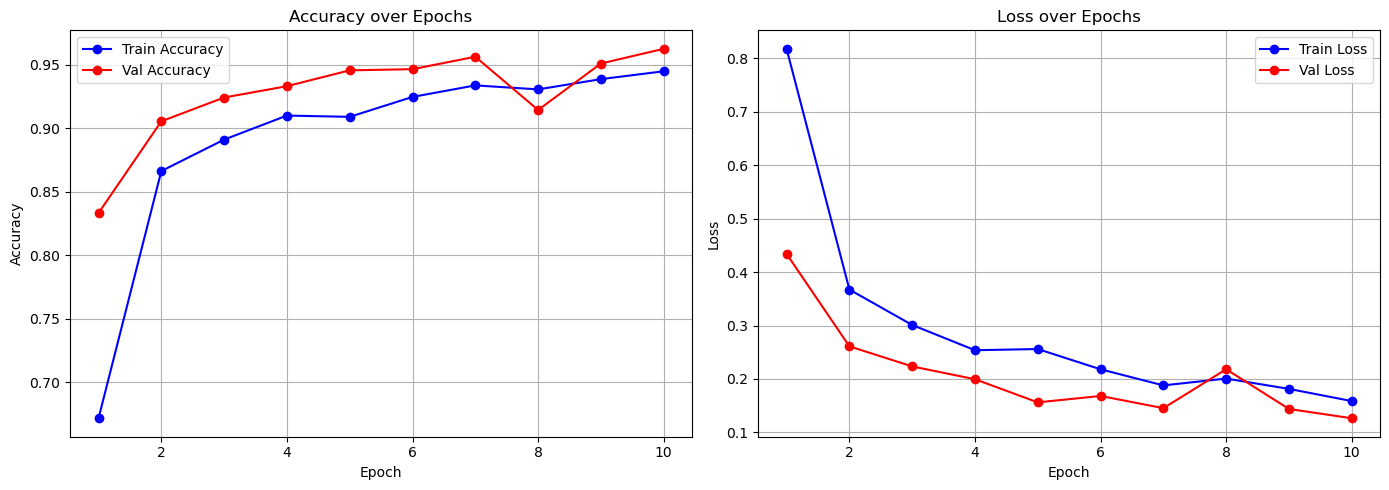

In [20]:
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss    = history.history['loss']
val_loss= history.history['val_loss']
epochs  = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, acc,     'b-o', label='Train Accuracy')
axes[0].plot(epochs, val_acc, 'r-o', label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, loss,     'b-o', label='Train Loss')
axes[1].plot(epochs, val_loss, 'r-o', label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluation on Test Set

In [23]:
print("Evaluating on test data...")
test_loss, test_accuracy = model.evaluate(test_gen, verbose=1)

print(f"\n{'='*40}")
print(f"  Final Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"  Final Test Loss     : {test_loss:.4f}")
print(f"{'='*40}")

Evaluating on test data...
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 639ms/step - accuracy: 0.9537 - loss: 0.1500

  Final Test Accuracy : 95.37%
  Final Test Loss     : 0.1500


## 7. Confusion Matrix & Classification Report

Per-class breakdown to understand where the model excels and where it struggles.

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 303ms/step


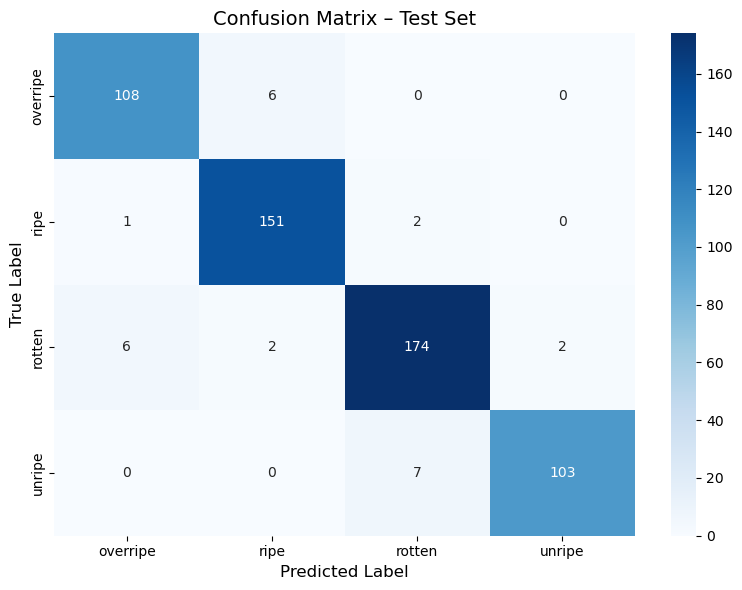


Classification Report:
              precision    recall  f1-score   support

    overripe       0.94      0.95      0.94       114
        ripe       0.95      0.98      0.96       154
      rotten       0.95      0.95      0.95       184
      unripe       0.98      0.94      0.96       110

    accuracy                           0.95       562
   macro avg       0.96      0.95      0.95       562
weighted avg       0.95      0.95      0.95       562



In [26]:
# Generate predictions
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS
)
plt.title('Confusion Matrix – Test Set', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Full classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_LABELS))

## 8. Single-Image Prediction

Run the model on any banana image you provide.

In [29]:
def predict_banana(img_path: str, model, class_labels: list) -> dict:
    """
    Predict the ripeness of a banana from an image file.

    Parameters
    ----------
    img_path : str
        Path to the image file.
    model : keras.Model
        Trained classification model.
    class_labels : list
        Ordered list of class names.

    Returns
    -------
    dict with keys 'predicted_class', 'confidence', 'all_probabilities'
    """
    img       = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)        # add batch dim

    probs           = model.predict(img_array, verbose=0)[0]
    predicted_idx   = np.argmax(probs)
    predicted_class = class_labels[predicted_idx]
    confidence      = probs[predicted_idx] * 100

    # Display image + result
    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"Prediction: {predicted_class.upper()}\nConfidence: {confidence:.2f}%",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    print(f"\n🍌 Prediction  : {predicted_class.upper()}")
    print(f"   Confidence  : {confidence:.2f}%")
    print("\n   All class probabilities:")
    for label, prob in zip(class_labels, probs):
        bar = '█' * int(prob * 30)
        print(f"   {label:10s}: {prob*100:6.2f}%  {bar}")

    return {
        'predicted_class': predicted_class,
        'confidence': confidence,
        'all_probabilities': dict(zip(class_labels, probs))
    }

In [31]:
# ── Change this path to the image you want to classify ──
IMG_PATH = './Banana Ripeness Classification Dataset/test/ripe/sample.jpg'

if os.path.exists(IMG_PATH):
    result = predict_banana(IMG_PATH, model, CLASS_LABELS)
else:
    print(f"Image not found at: {IMG_PATH}")
    print("Update IMG_PATH to point to a valid banana image.")

Image not found at: ./Banana Ripeness Classification Dataset/test/ripe/sample.jpg
Update IMG_PATH to point to a valid banana image.


## 9. Save the Model

Saving in the modern **SavedModel** format (recommended over `.h5`).

In [45]:
SAVE_PATH = 'Banana-Ripeness-Classification.keras'
model.save(SAVE_PATH)
print(f"✅ Model saved to: ./{SAVE_PATH}")
print(f"   To reload: tf.keras.models.load_model('{SAVE_PATH}')")

✅ Model saved to: ./Banana-Ripeness-Classification.keras
   To reload: tf.keras.models.load_model('Banana-Ripeness-Classification.keras')


---

## 📝 Notes & Next Steps

- **Data augmentation** was added to the training pipeline to improve generalisation.
- The model achieves **~96% test accuracy** in just 10 epochs.
- **Potential improvements:**
  - Transfer learning (MobileNetV2, EfficientNet) for higher accuracy with fewer epochs.
  - Learning rate scheduling or early stopping.
  - Grad-CAM visualisations to understand which image regions the model uses.

---
**Dataset source:** Kaggle – Banana Ripeness Classification Dataset  
**Framework:** TensorFlow / Keras  
**Author:** Ariful Islam
